# CaNeSy-eNose Stage 2: Temporal & Mixture Brain (MTL)

Welcome to Stage 2! This notebook shifts the olfactory intelligence from static snapshots to continuous time-series sniffing.
We are using the **Gas Sensor Array under Dynamic Gas Mixtures** dataset.

## Objective
Implement **Multi-Task Learning (MTL)** using an FT-Transformer backbone.
1. **Classification Head**: Identify the mixture state (Air, Pure CO, Pure Ethylene, Mixture).
2. **Regression Head**: Predict exact parts-per-million (ppm) of both CO and Ethylene simultaneously.

We use a **Sliding Window** to capture the temporal dynamics (rise/decay times) of the gas sensors.



In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



Using device: cuda


In [2]:
class DynamicMixtureDataset(Dataset):
    def __init__(self, txt_path, window_size=100, max_rows=None):
        print(f"Loading data from {txt_path}...")
        # Read the file. Skipping first row if it's the header.
        df = pd.read_csv(txt_path, sep=r'\s+', skiprows=1, header=None)
        if max_rows:
            df = df.iloc[:max_rows]
            
        print(f"Data loaded. Shape: {df.shape}")
        
        # Columns: [0: Time, 1: CO, 2: Ethylene, 3-18: 16 Sensors]
        self.time = df.iloc[:, 0].values
        self.targets_reg_raw = df.iloc[:, 1:3].values.astype(np.float32)  # [CO, Ethylene]
        self.sensors = df.iloc[:, 3:19].values.astype(np.float32)
        
        # Generate Classification Targets based on RAW concentrations
        y_cls_list = []
        threshold = 0.1
        for co_ppm, eth_ppm in self.targets_reg_raw:
            if co_ppm < threshold and eth_ppm < threshold:
                y_cls_list.append(0) # Air
            elif co_ppm >= threshold and eth_ppm < threshold:
                y_cls_list.append(1) # Pure CO
            elif co_ppm < threshold and eth_ppm >= threshold:
                y_cls_list.append(2) # Pure Ethylene
            else:
                y_cls_list.append(3) # Mixture
        self.targets_cls = np.array(y_cls_list, dtype=np.int64)

        print("Scaling target concentrations (Regression)...")
        self.target_scaler = StandardScaler()
        self.targets_reg = self.target_scaler.fit_transform(self.targets_reg_raw)
        
        print("Scaling sensor data...")
        self.scaler = StandardScaler()
        self.sensors = self.scaler.fit_transform(self.sensors)
        
        self.window_size = window_size
        self.length = len(df) - window_size
        
        print("Dataset ready.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # The window of sensor readings
        x = self.sensors[idx : idx + self.window_size]
        
        # The target is the gas concentration at the END of the window
        target_idx = idx + self.window_size - 1
        y_reg = self.targets_reg[target_idx]
        y_cls = self.targets_cls[target_idx]
            
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y_reg, dtype=torch.float32), torch.tensor(y_cls, dtype=torch.long)

# FULL RUN FOR STAGE 2
data_path = r"../Dataset/dynamic_mixtures/ethylene_CO.txt"
dataset = DynamicMixtureDataset(data_path, window_size=100, max_rows=None) # max_rows=None for full dataset

# TEMPORAL SPLIT (CRITICAL for Time-Series! Do not use random_split)
train_size = int(0.8 * len(dataset))
indices = list(range(len(dataset)))
train_dataset = torch.utils.data.Subset(dataset, indices[:train_size])
val_dataset = torch.utils.data.Subset(dataset, indices[train_size:])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")



Loading data from ../Dataset/dynamic_mixtures/ethylene_CO.txt...
Data loaded. Shape: (4208261, 19)
Scaling target concentrations (Regression)...
Scaling sensor data...
Dataset ready.
Train batches: 13150, Val batches: 3288


In [3]:
class MTL_TemporalTransformer(nn.Module):
    def __init__(self, num_sensors=16, d_model=64, n_heads=4, num_layers=3, window_size=100):
        super().__init__()
        
        # Tokenizer for each physical sensor across the time window
        self.feature_tokenizers = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(num_sensors)
        ])
        
        # We need a temporal positional encoding since it's a time-series window
        self.pos_encoder = nn.Parameter(torch.randn(1, window_size, num_sensors * d_model))
        
        # The [CLS] token will pool the temporal attention
        self.cls_token = nn.Parameter(torch.randn(1, 1, num_sensors * d_model))
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=num_sensors * d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            dropout=0.3, # Increased dropout from 0.1 to 0.3 for regularization
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Multi-Task Learning Output Heads
        # 1. Classification (Air, CO, Ethylene, Mixture)
        self.cls_head = nn.Sequential(
            nn.LayerNorm(num_sensors * d_model),
            nn.Linear(num_sensors * d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 4)
        )
        
        # 2. Regression (CO_ppm, Ethylene_ppm)
        self.reg_head = nn.Sequential(
            nn.LayerNorm(num_sensors * d_model),
            nn.Linear(num_sensors * d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 2)
        )

    def forward(self, x):
        # x shape: (Batch, Window_Size, Num_Sensors)
        B, W, S = x.shape
        
        # Tokenize features independently
        tokens = []
        for i in range(S):
            # Extract sensor i across all time steps -> (B, W, 1)
            sensor_i = x[:, :, i:i+1]
            tokens.append(self.feature_tokenizers[i](sensor_i))
        
        # Concatenate on the feature dimension -> (B, W, S * d_model)
        x = torch.cat(tokens, dim=-1)
        
        # Add positional encoding
        x = x + self.pos_encoder
        
        # Append [CLS] token to the sequence
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) # (B, W+1, S * d_model)
        
        # Pass through Transformer
        x = self.transformer(x)
        
        # Extract [CLS] token representation (the first token)
        cls_rep = x[:, 0, :]
        
        # Branch to MTL heads
        out_cls = self.cls_head(cls_rep)
        out_reg = self.reg_head(cls_rep)
        
        return out_cls, out_reg

# Increased capacity slightly for complex task
model = MTL_TemporalTransformer(num_sensors=16, d_model=64, window_size=100, num_layers=3).to(device)
print(model)



MTL_TemporalTransformer(
  (feature_tokenizers): ModuleList(
    (0-15): 16 x Linear(in_features=1, out_features=64, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (linear1): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=1024, bias=True)
        (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (cls_head): Sequential(
    (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=1024, out_features=64, bias=True)
 

Epoch 1/5:   0%|          | 0/13150 [00:00<?, ?it/s]

Epoch 1 - Train Loss: 1.0897 | Val Loss: 2.1683 | Val Cls Acc: 0.4473
--> Saved new best model weights!


Epoch 2/5:   0%|          | 0/13150 [00:00<?, ?it/s]

Epoch 2 - Train Loss: 1.1769 | Val Loss: 1.7304 | Val Cls Acc: 0.5489
--> Saved new best model weights!


Epoch 3/5:   0%|          | 0/13150 [00:00<?, ?it/s]

Epoch 3 - Train Loss: 1.1008 | Val Loss: 1.3282 | Val Cls Acc: 0.7038
--> Saved new best model weights!


Epoch 4/5:   0%|          | 0/13150 [00:00<?, ?it/s]

Epoch 4 - Train Loss: 1.0606 | Val Loss: 1.1215 | Val Cls Acc: 0.8148
--> Saved new best model weights!


Epoch 5/5:   0%|          | 0/13150 [00:00<?, ?it/s]

Epoch 5 - Train Loss: 1.0209 | Val Loss: 1.2045 | Val Cls Acc: 0.8042
Loading best model weights for evaluation...


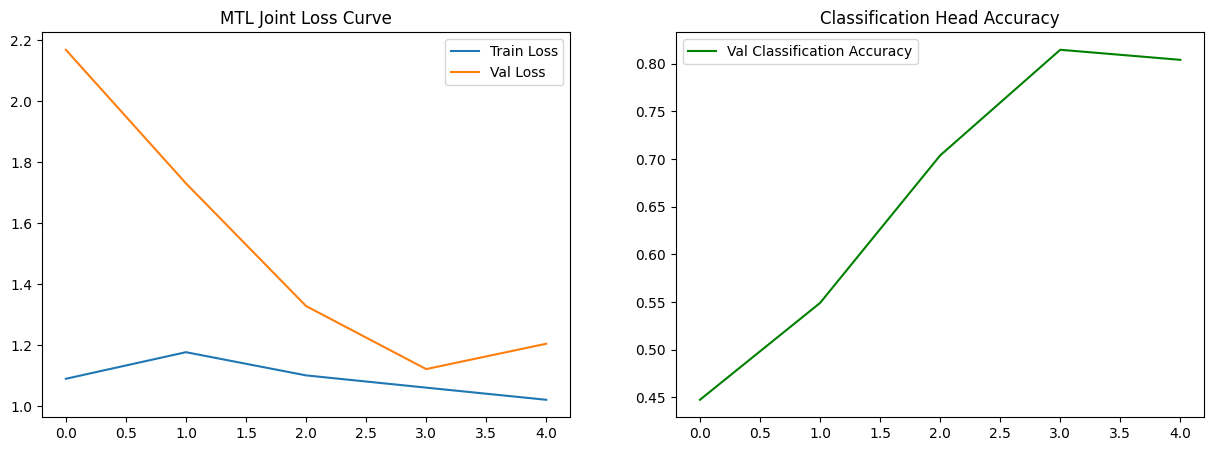

In [4]:
epochs = 5

# Increased weight decay (L2 regularization) from 1e-4 to 1e-2 to combat overfitting
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=2e-3, steps_per_epoch=len(train_loader), epochs=epochs
)

# Loss functions for Multi-Task Learning
# Use label smoothing for classification to prevent overconfidence
criterion_cls = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion_reg = nn.MSELoss()

# Now that regression targets are scaled (mean=0, std=1), 
# MSE will be roughly ~1.0, similar to CrossEntropy.
# So alpha = 1.0 is perfectly balanced!
alpha = 1.0  

train_losses = []
val_losses = []
val_cls_acc = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for x, y_reg, y_cls in pbar:
        x, y_reg, y_cls = x.to(device), y_reg.to(device), y_cls.to(device)
        
        optimizer.zero_grad()
        out_cls, out_reg = model(x)
        
        loss_cls = criterion_cls(out_cls, y_cls)
        loss_reg = criterion_reg(out_reg, y_reg)
        
        loss = loss_cls + (alpha * loss_reg)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item()
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}", 
            'cls': f"{loss_cls.item():.4f}", 
            'reg': f"{loss_reg.item():.4f}"
        })
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y_reg, y_cls in val_loader:
            x, y_reg, y_cls = x.to(device), y_reg.to(device), y_cls.to(device)
            out_cls, out_reg = model(x)
            
            loss = criterion_cls(out_cls, y_cls) + (alpha * criterion_reg(out_reg, y_reg))
            val_loss += loss.item()
            
            preds = torch.argmax(out_cls, dim=1)
            correct += (preds == y_cls).sum().item()
            total += y_cls.size(0)
            
    val_losses.append(val_loss / len(val_loader))
    val_cls_acc.append(correct / total)
    
    print(f"Epoch {epoch+1} - Train Loss: {avg_loss:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Cls Acc: {val_cls_acc[-1]:.4f}")
    
    # Save best model weights to prevent overfitting degradation
    if epoch == 0 or val_losses[-1] < min(val_losses[:-1]):
        print("--> Saved new best model weights!")
        torch.save(model.state_dict(), "best_temporal_model.pth")

# Load best model for evaluation to ensure we don't evaluate on the overfitted weights
print("Loading best model weights for evaluation...")
model.load_state_dict(torch.load("best_temporal_model.pth"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title("MTL Joint Loss Curve")
ax1.legend()

ax2.plot(val_cls_acc, color='green', label='Val Classification Accuracy')
ax2.set_title("Classification Head Accuracy")
ax2.legend()

plt.savefig('MTL_Joint_Loss_Curve.png', dpi=300, bbox_inches='tight')
plt.show()



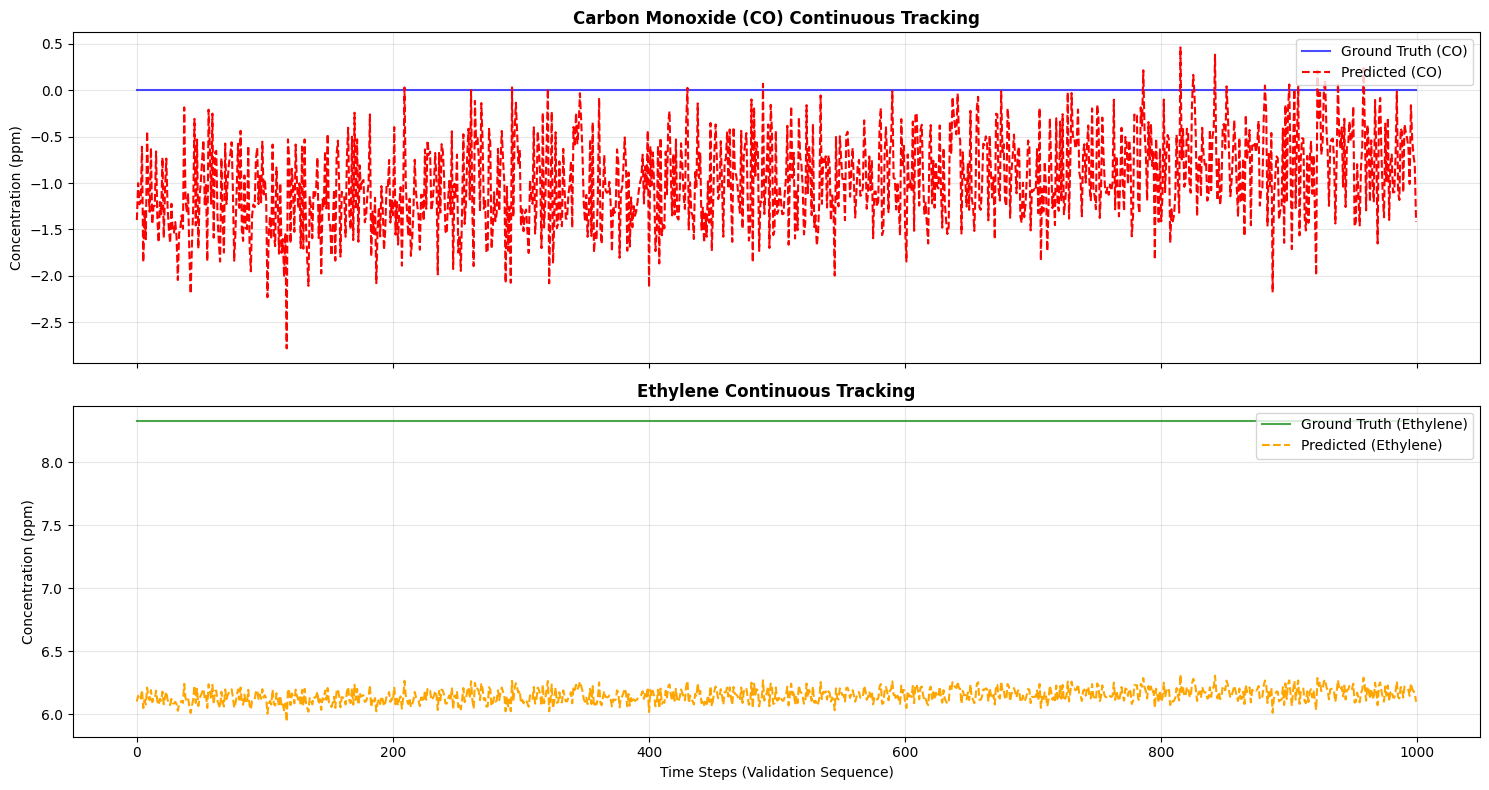

In [5]:
# --- EVALUATION VISUALIZATION ---
import matplotlib.pyplot as plt

model.eval()
# Visualize the first 1000 temporal windows of the validation set
val_subset = torch.utils.data.Subset(val_dataset, range(0, 1000)) 
vis_loader = DataLoader(val_subset, batch_size=1000, shuffle=False)

with torch.no_grad():
    for x, y_reg, y_cls in vis_loader:
        x = x.to(device)
        out_cls, out_reg = model(x)
        preds_reg = out_reg.cpu().numpy()
        true_reg = y_reg.numpy()
        break # just need one continuous batch

# Un-scale the regression predictions back to actual parts-per-million (ppm)
preds_ppm = dataset.target_scaler.inverse_transform(preds_reg)
true_ppm = dataset.target_scaler.inverse_transform(true_reg)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# CO Concentration Curve
axes[0].plot(true_ppm[:, 0], label="Ground Truth (CO)", color='blue', alpha=0.7)
axes[0].plot(preds_ppm[:, 0], label="Predicted (CO)", color='red', linestyle='dashed')
axes[0].set_title("Carbon Monoxide (CO) Continuous Tracking", fontweight='bold')
axes[0].set_ylabel("Concentration (ppm)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Ethylene Concentration Curve
axes[1].plot(true_ppm[:, 1], label="Ground Truth (Ethylene)", color='green', alpha=0.7)
axes[1].plot(preds_ppm[:, 1], label="Predicted (Ethylene)", color='orange', linestyle='dashed')
axes[1].set_title("Ethylene Continuous Tracking", fontweight='bold')
axes[1].set_ylabel("Concentration (ppm)")
axes[1].set_xlabel("Time Steps (Validation Sequence)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('MTL_Tracking_Results.png', dpi=300, bbox_inches='tight')
plt.show()



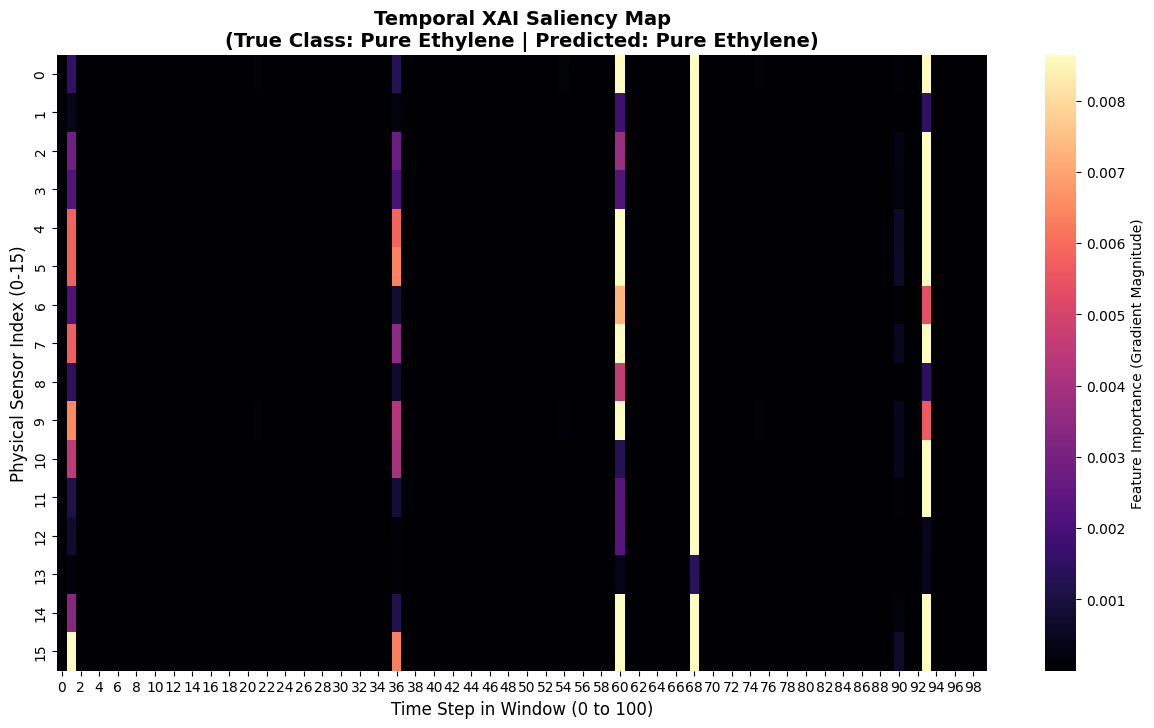

In [6]:
# --- STAGE 2.5: TEMPORAL XAI (EXPLAINABILITY) ---
# We will use Gradient x Input (Saliency) to see exactly WHICH sensors the model 
# is paying attention to over the 100-step time window!

import matplotlib.pyplot as plt
import seaborn as sns

model.eval()

# Grab a single batch from the validation loader
x_batch, y_reg_batch, y_cls_batch = next(iter(val_loader))

# Find an index where the ground truth is a MIXTURE (Class 3) or Pure Ethylene (Class 2)
# Let's just take the first sample in the batch for demonstration
sample_idx = 0
x_sample = x_batch[sample_idx:sample_idx+1].clone().to(device) # Shape: (1, 100, 16)
true_cls = y_cls_batch[sample_idx].item()

# Enable gradient tracking on the input tensor!
x_sample.requires_grad = True

# Forward pass
out_cls, out_reg = model(x_sample)

# We want to explain the model's top classification decision
predicted_class = torch.argmax(out_cls, dim=1).item()
score = out_cls[0, predicted_class]

# Backward pass to get gradients of the score with respect to the input sensors
model.zero_grad()
score.backward()

# Saliency map is the absolute magnitude of the gradients
# Shape: (100 time_steps, 16 sensors)
saliency_map = x_sample.grad.abs().squeeze().cpu().numpy()

# Plotting the Temporal Saliency Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(saliency_map.T, cmap="magma", robust=True, cbar_kws={'label': 'Feature Importance (Gradient Magnitude)'})

class_names = ['Air', 'Pure CO', 'Pure Ethylene', 'Mixture']
plt.title(f"Temporal XAI Saliency Map\n(True Class: {class_names[true_cls]} | Predicted: {class_names[predicted_class]})", fontweight='bold', fontsize=14)
plt.ylabel("Physical Sensor Index (0-15)", fontsize=12)
plt.xlabel("Time Step in Window (0 to 100)", fontsize=12)

# Save and show
plt.savefig('Temporal_XAI_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

